In [ ]:
# Instalação e importações de bibliotecas

import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

df = pd.read_excel('https://drive.google.com/uc?export=download&id=1LGQWS6zN8yc7coP-HrWm5MygUUyp1afX')

display(df.head(6))

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,ARM,Armenia,Asia,Western Asia,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,35.0,CTS
1,CHE,Switzerland,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,28.0,CTS
2,COL,Colombia,Americas,Latin America and the Caribbean,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,15053.0,CTS
3,CZE,Czechia,Europe,Eastern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,69.0,CTS
4,DEU,Germany,Europe,Western Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,455.0,CTS
5,FIN,Finland,Europe,Northern Europe,Persons arrested/suspected for intentional hom...,by citizenship,National citizens,Male,Total,2013,Counts,70.0,CTS


In [ ]:
# Limpeza e Filtragem dos Dados


df_filtrado = df[(df['Year'] >= 2013) & (df['Year'] <= 2022)].copy()
df_homicidios = df_filtrado[df_filtrado['Indicator'] == 'Victims of intentional homicide'].copy()

# Colunas a serem utilizadas
colunas_uteis = ['Country', 'Region', 'Subregion', 'Indicator', 'Sex', 'Year', 'VALUE']
df_clean = df_homicidios[colunas_uteis]


display(df_clean.head())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE
4218,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,6.0
4219,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,1.0
4220,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0
4221,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0
4222,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0


### Regressão Linear Simples para Predição de Homicídios

In [ ]:
# Agrupar os dados por ano e somar os valores para obter o total de homicídios por ano
df_yearly_homicides = df_clean.groupby('Year')['VALUE'].sum().reset_index()

display(df_yearly_homicides.head())

,Year,VALUE
0,2013,8.074636e+05
1,2014,8.588628e+05
2,2015,9.827408e+05
3,2016,1.220702e+06
4,2017,1.214491e+06


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparar os dados para a regressão
X = df_yearly_homicides[['Year']].values # Variável independente (Ano)
y = df_yearly_homicides['VALUE'].values # Variável dependente (Número de Homicídios)

# Criar e treinar o modelo de regressão linear
model = LinearRegression()
model.fit(X, y)

# Anos para os quais queremos fazer a previsão (2023, 2024, 2025, 2026)
future_years = np.array([2023, 2024, 2025, 2026]).reshape(-1, 1)

# Fazer as previsões
predictions = model.predict(future_years)

# Criar um DataFrame com as previsões
df_predictions = pd.DataFrame({
    'Year': future_years.flatten(),
    'VALUE': predictions
})

display(df_predictions)

,Year,VALUE
0,2023,1.137536e+06
1,2024,1.150460e+06
2,2025,1.163384e+06
3,2026,1.176308e+06


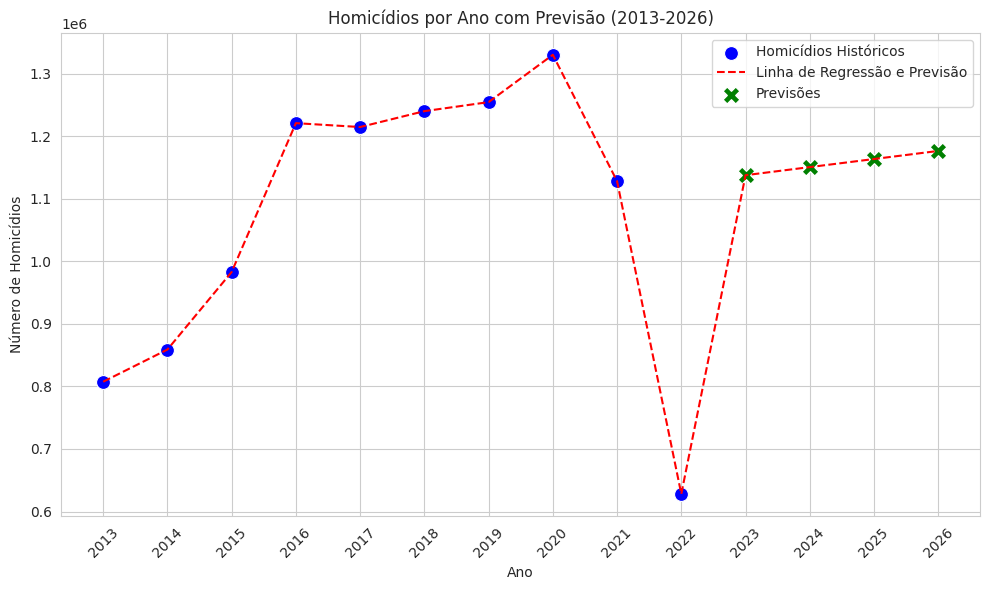

In [ ]:
# Combinar dados históricos e previsões para o gráfico
df_combined = pd.concat([df_yearly_homicides, df_predictions])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='VALUE', data=df_yearly_homicides, label='Homicídios Históricos', color='blue', s=100)
sns.lineplot(x='Year', y='VALUE', data=df_combined, label='Linha de Regressão e Previsão', color='red', linestyle='--')
sns.scatterplot(x='Year', y='VALUE', data=df_predictions, label='Previsões', color='green', marker='X', s=150)

plt.title('Homicídios por Ano com Previsão (2013-2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(df_combined['Year'].unique(), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Regressão Linear para Homicídios no Brasil

In [ ]:
# Filtrar os dados apenas para o Brasil
df_brasil = df_clean[df_clean['Country'] == 'Brazil'].copy()

# Agrupar os dados por ano e somar os valores para obter o total de homicídios anuais para o Brasil
df_yearly_homicides_brasil = df_brasil.groupby('Year')['VALUE'].sum().reset_index()

display(df_yearly_homicides_brasil.head())

,Year,VALUE
0,2013,113670.146904
1,2014,119441.724109
2,2015,116355.723168
3,2016,122406.478925
4,2017,127561.527274


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Preparar os dados para a regressão para o Brasil
X_brasil = df_yearly_homicides_brasil[['Year']].values # Variável independente (Ano)
y_brasil = df_yearly_homicides_brasil['VALUE'].values # Variável dependente (Número de Homicídios)

# Criar e treinar o modelo de regressão linear para o Brasil
model_brasil = LinearRegression()
model_brasil.fit(X_brasil, y_brasil)

# Anos para os quais queremos fazer a previsão (2023, 2024, 2025, 2026)
future_years_brasil = np.array([2023, 2024, 2025, 2026]).reshape(-1, 1)

# Fazer as previsões para o Brasil
predictions_brasil = model_brasil.predict(future_years_brasil)

# Criar um DataFrame com as previsões para o Brasil
df_predictions_brasil = pd.DataFrame({
    'Year': future_years_brasil.flatten(),
    'VALUE': predictions_brasil
})

display(df_predictions_brasil)

,Year,VALUE
0,2023,141062.075780
1,2024,143861.201376
2,2025,146660.326971
3,2026,149459.452566


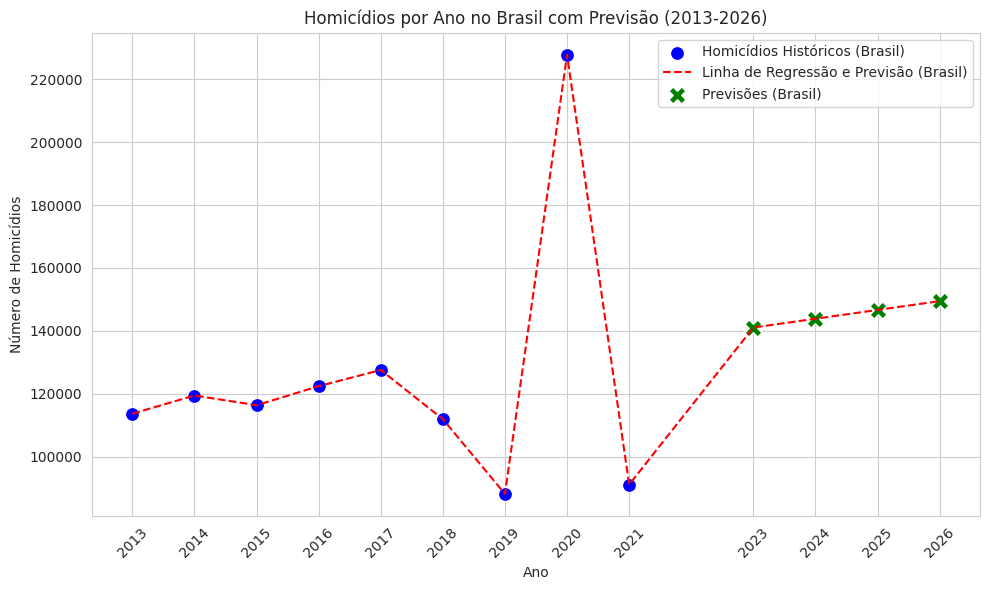

In [ ]:
# Combinar dados históricos e previsões para o gráfico do Brasil
df_combined_brasil = pd.concat([df_yearly_homicides_brasil, df_predictions_brasil])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='VALUE', data=df_yearly_homicides_brasil, label='Homicídios Históricos (Brasil)', color='blue', s=100)
sns.lineplot(x='Year', y='VALUE', data=df_combined_brasil, label='Linha de Regressão e Previsão (Brasil)', color='red', linestyle='--')
sns.scatterplot(x='Year', y='VALUE', data=df_predictions_brasil, label='Previsões (Brasil)', color='green', marker='X', s=150)

plt.title('Homicídios por Ano no Brasil com Previsão (2013-2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Homicídios')
plt.xticks(df_combined_brasil['Year'].unique(), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Regressão Linear: Comparativo das 10 Maiores Economias do Mundo

Nesta seção, analisamos a tendência de homicídios para as maiores economias, projetando os valores até 2026.

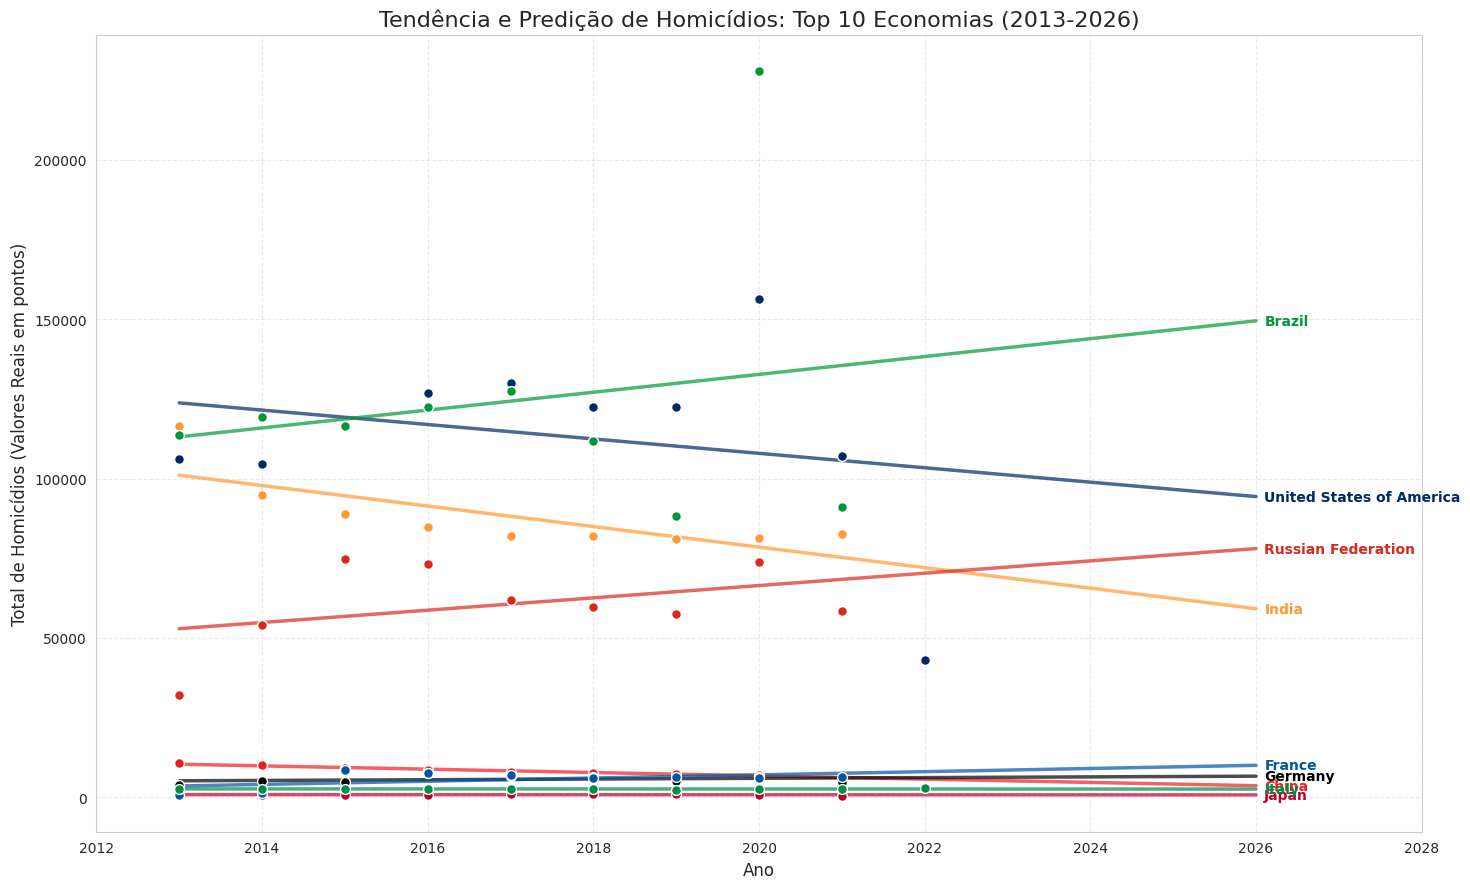

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Lista das 10 maiores economias
top_10_economies = {
    'United States of America': '#002868',
    'China': '#EE1C25',
    'Germany': '#000000',
    'Japan': '#BC002D',
    'United Kingdom': '#00247D',
    'India': '#FF9933',
    'France': '#0055A4',
    'Italy': '#008C45',
    'Russian Federation': '#DA291C',
    'Brazil': '#009739'
}

future_years = np.array([2023, 2024, 2025, 2026]).reshape(-1, 1)
plt.figure(figsize=(15, 9))

for country, color in top_10_economies.items():
    df_c = df_clean[df_clean['Country'] == country].groupby('Year')['VALUE'].sum().reset_index()

    if not df_c.empty:
        X_c = df_c[['Year']].values
        y_c = df_c['VALUE'].values

        model_c = LinearRegression()
        model_c.fit(X_c, y_c)

        preds_c = model_c.predict(future_years)

        years_full = np.append(df_c['Year'].values, future_years.flatten())
        preds_full = np.append(model_c.predict(X_c), preds_c)

        # Plotagem da linha de tendência e predição
        line, = plt.plot(years_full, preds_full, color=color, linewidth=2.5, alpha=0.7, label=country)

        # Plotagem dos pontos históricos (Valores Reais Totais)
        plt.scatter(df_c['Year'], df_c['VALUE'], color=color, s=50, edgecolors='white', zorder=5)

        # Adicionar nome do país ao final da linha para facilitar identificação
        plt.text(years_full[-1] + 0.1, preds_full[-1], country, color=color, fontweight='bold', va='center')

plt.title('Tendência e Predição de Homicídios: Top 10 Economias (2013-2026)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Homicídios (Valores Reais em pontos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(2012, 2028) # Espaço extra para os nomes
plt.tight_layout()
plt.show()

### 2. Regressão Linear por Sexo

#### Homicídios Masculinos

In [ ]:
# Filtrar dados para homicídios masculinos
df_homicides_male = df_clean[df_clean['Sex'] == 'Male'].groupby('Year')['VALUE'].sum().reset_index()

# Preparar dados para regressão
X_male = df_homicides_male[['Year']].values
y_male = df_homicides_male['VALUE'].values

# Criar e treinar o modelo de regressão linear
model_male = LinearRegression()
model_male.fit(X_male, y_male)

# Anos para previsão (já definidos como future_years)
predictions_male = model_male.predict(future_years)

# Criar DataFrame com previsões
df_predictions_male = pd.DataFrame({
    'Year': future_years.flatten(),
    'VALUE': predictions_male
})

# Combinar dados históricos e previsões
df_combined_male = pd.concat([df_homicides_male, df_predictions_male])

display(df_predictions_male.head())

,Year,VALUE
0,2023,465172.183607
1,2024,475304.860644
2,2025,485437.537682
3,2026,495570.214720


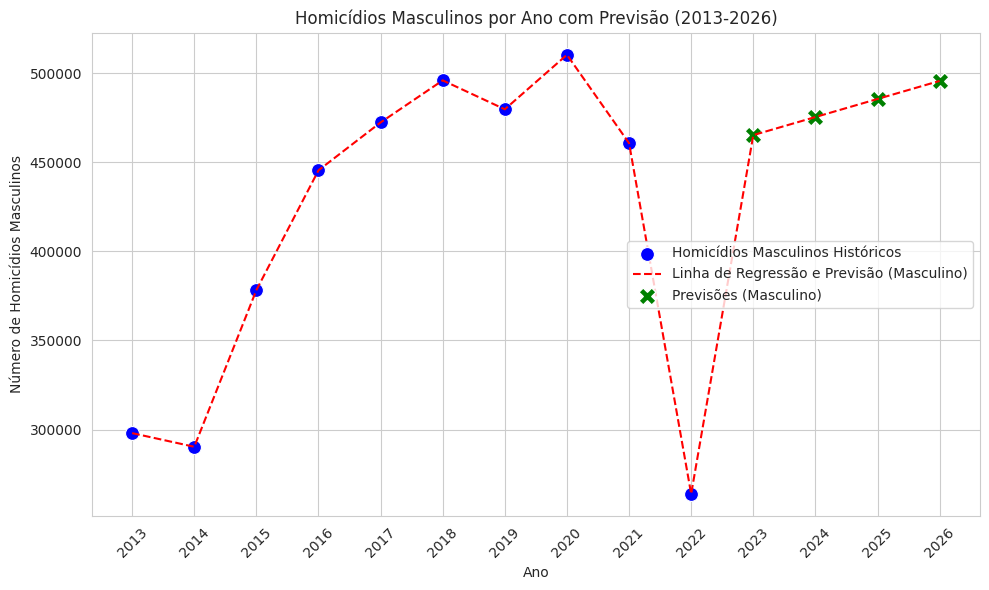

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='VALUE', data=df_homicides_male, label='Homicídios Masculinos Históricos', color='blue', s=100)
sns.lineplot(x='Year', y='VALUE', data=df_combined_male, label='Linha de Regressão e Previsão (Masculino)', color='red', linestyle='--')
sns.scatterplot(x='Year', y='VALUE', data=df_predictions_male, label='Previsões (Masculino)', color='green', marker='X', s=150)

plt.title('Homicídios Masculinos por Ano com Previsão (2013-2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Homicídios Masculinos')
plt.xticks(df_combined_male['Year'].unique(), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Homicídios Femininos

In [ ]:
# Filtrar dados para homicídios femininos
df_homicides_female = df_clean[df_clean['Sex'] == 'Female'].groupby('Year')['VALUE'].sum().reset_index()

# Preparar dados para regressão
X_female = df_homicides_female[['Year']].values
y_female = df_homicides_female['VALUE'].values

# Criar e treinar o modelo de regressão linear
model_female = LinearRegression()
model_female.fit(X_female, y_female)

# Anos para previsão
predictions_female = model_female.predict(future_years)

# Criar DataFrame com previsões
df_predictions_female = pd.DataFrame({
    'Year': future_years.flatten(),
    'VALUE': predictions_female
})

# Combinar dados históricos e previsões
df_combined_female = pd.concat([df_homicides_female, df_predictions_female])

display(df_predictions_female.head())

,Year,VALUE
0,2023,82434.920976
1,2024,81783.880575
2,2025,81132.840174
3,2026,80481.799773


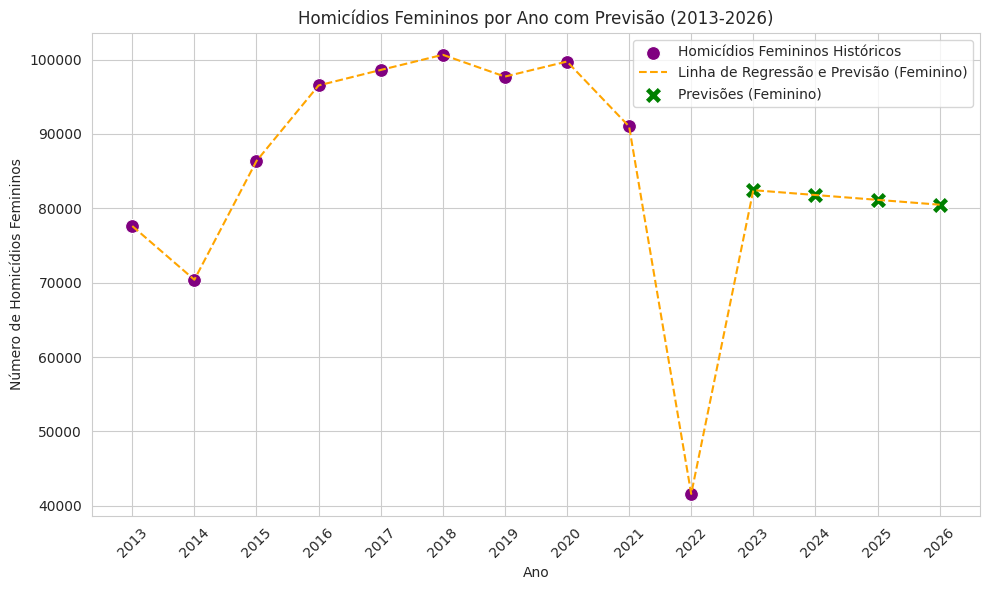

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='VALUE', data=df_homicides_female, label='Homicídios Femininos Históricos', color='purple', s=100)
sns.lineplot(x='Year', y='VALUE', data=df_combined_female, label='Linha de Regressão e Previsão (Feminino)', color='orange', linestyle='--')
sns.scatterplot(x='Year', y='VALUE', data=df_predictions_female, label='Previsões (Feminino)', color='green', marker='X', s=150)

plt.title('Homicídios Femininos por Ano com Previsão (2013-2026)')
plt.xlabel('Ano')
plt.ylabel('Número de Homicídios Femininos')
plt.xticks(df_combined_female['Year'].unique(), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Razão de Homicídios Femininos por Masculinos

In [ ]:
# Preparar dados para cálculo da razão
df_male_yearly = df_clean[df_clean['Sex'] == 'Male'].groupby('Year')['VALUE'].sum().reset_index()
df_female_yearly = df_clean[df_clean['Sex'] == 'Female'].groupby('Year')['VALUE'].sum().reset_index()

# Mesclar os DataFrames e calcular a razão
df_sex_ratio = pd.merge(df_female_yearly, df_male_yearly, on='Year', suffixes=('_female', '_male'))
df_sex_ratio['Ratio_Female_to_Male'] = df_sex_ratio['VALUE_female'] / df_sex_ratio['VALUE_male']

# Preparar dados para regressão da razão
X_ratio = df_sex_ratio[['Year']].values
y_ratio = df_sex_ratio['Ratio_Female_to_Male'].values

# Criar e treinar o modelo de regressão linear para a razão
model_ratio = LinearRegression()
model_ratio.fit(X_ratio, y_ratio)

# Anos para previsão
predictions_ratio = model_ratio.predict(future_years)

# Criar DataFrame com previsões da razão
df_predictions_ratio = pd.DataFrame({
    'Year': future_years.flatten(),
    'Ratio_Female_to_Male': predictions_ratio
})

# Combinar dados históricos e previsões da razão
df_combined_ratio = pd.concat([df_sex_ratio[['Year', 'Ratio_Female_to_Male']], df_predictions_ratio])

display(df_predictions_ratio.head())

,Year,Ratio_Female_to_Male
0,2023,0.163098
1,2024,0.154315
2,2025,0.145532
3,2026,0.136749


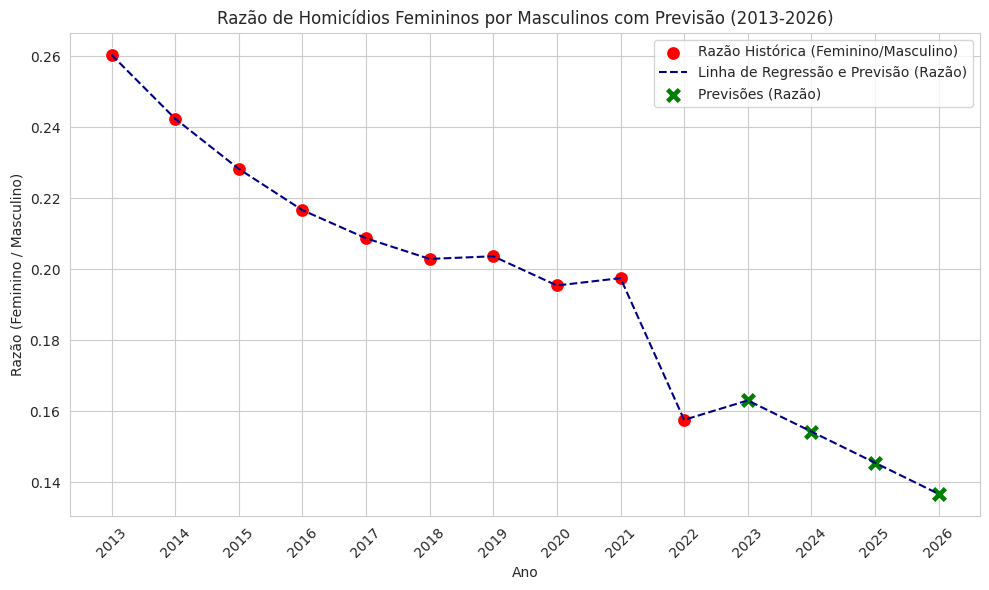

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Year', y='Ratio_Female_to_Male', data=df_sex_ratio, label='Razão Histórica (Feminino/Masculino)', color='red', s=100)
sns.lineplot(x='Year', y='Ratio_Female_to_Male', data=df_combined_ratio, label='Linha de Regressão e Previsão (Razão)', color='darkblue', linestyle='--')
sns.scatterplot(x='Year', y='Ratio_Female_to_Male', data=df_predictions_ratio, label='Previsões (Razão)', color='green', marker='X', s=150)

plt.title('Razão de Homicídios Femininos por Masculinos com Previsão (2013-2026)')
plt.xlabel('Ano')
plt.ylabel('Razão (Feminino / Masculino)')
plt.xticks(df_combined_ratio['Year'].unique(), rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 3. Regressão por Região/Sub-região

#### Tendência Temporal Regional das Maiores Regiões

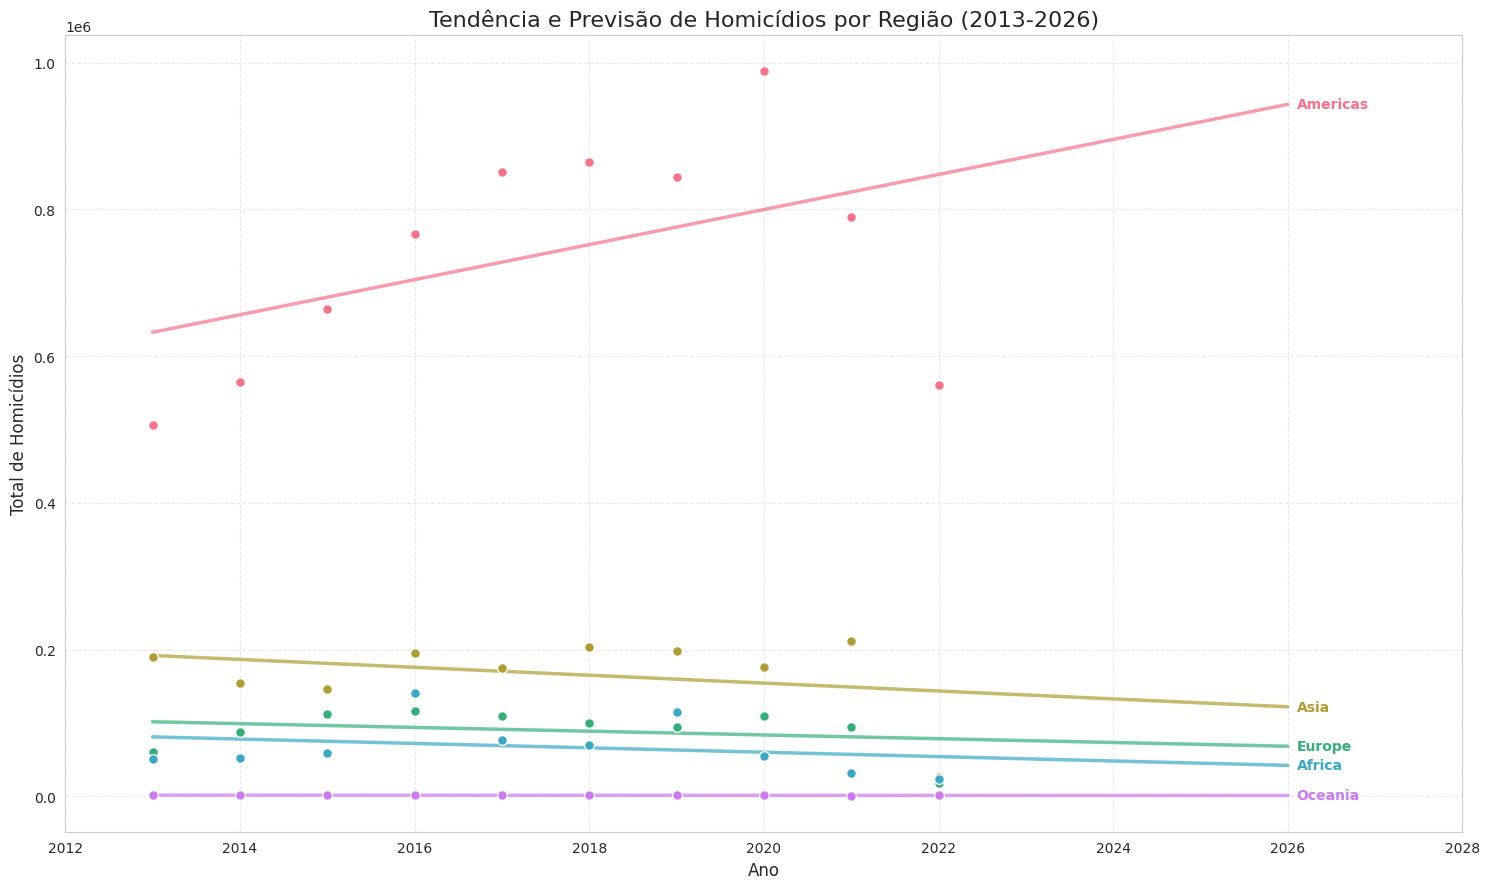

In [ ]:
# Agrupar dados por Região e Ano
df_regional_homicides = df_clean.groupby(['Region', 'Year'])['VALUE'].sum().reset_index()

# Identificar as 7 regiões com maior número total de homicídios no período histórico
top_regions = df_regional_homicides.groupby('Region')['VALUE'].sum().nlargest(7).index.tolist()

plt.figure(figsize=(15, 9))

# Gerar uma paleta de cores para as regiões
palette = sns.color_palette("husl", len(top_regions))
region_colors = {region: color for region, color in zip(top_regions, palette)}

for region in top_regions:
    df_r = df_regional_homicides[df_regional_homicides['Region'] == region].copy()

    if not df_r.empty:
        X_r = df_r[['Year']].values
        y_r = df_r['VALUE'].values

        model_r = LinearRegression()
        model_r.fit(X_r, y_r)

        # Previsões para os anos futuros
        preds_r = model_r.predict(future_years)

        # Combinar anos históricos e futuros para o plot
        years_full_r = np.append(df_r['Year'].values, future_years.flatten())
        preds_full_r = np.append(model_r.predict(X_r), preds_r)

        # Plotagem da linha de tendência e predição
        plt.plot(years_full_r, preds_full_r, color=region_colors[region], linewidth=2.5, alpha=0.7, label=region)

        # Plotagem dos pontos históricos (Valores Reais Totais)
        plt.scatter(df_r['Year'], df_r['VALUE'], color=region_colors[region], s=50, edgecolors='white', zorder=5)

        # Adicionar nome da região ao final da linha
        plt.text(years_full_r[-1] + 0.1, preds_full_r[-1], region, color=region_colors[region], fontweight='bold', va='center')

plt.title('Tendência e Previsão de Homicídios por Região (2013-2026)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Homicídios', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(2012, 2028) # Espaço extra para os nomes
plt.tight_layout()
plt.show()

#### Dispersão Regional de Homicídios (Boxplots)

/tmp/ipykernel_4157/1925336731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='VALUE', data=df_regional_homicides, palette='viridis')


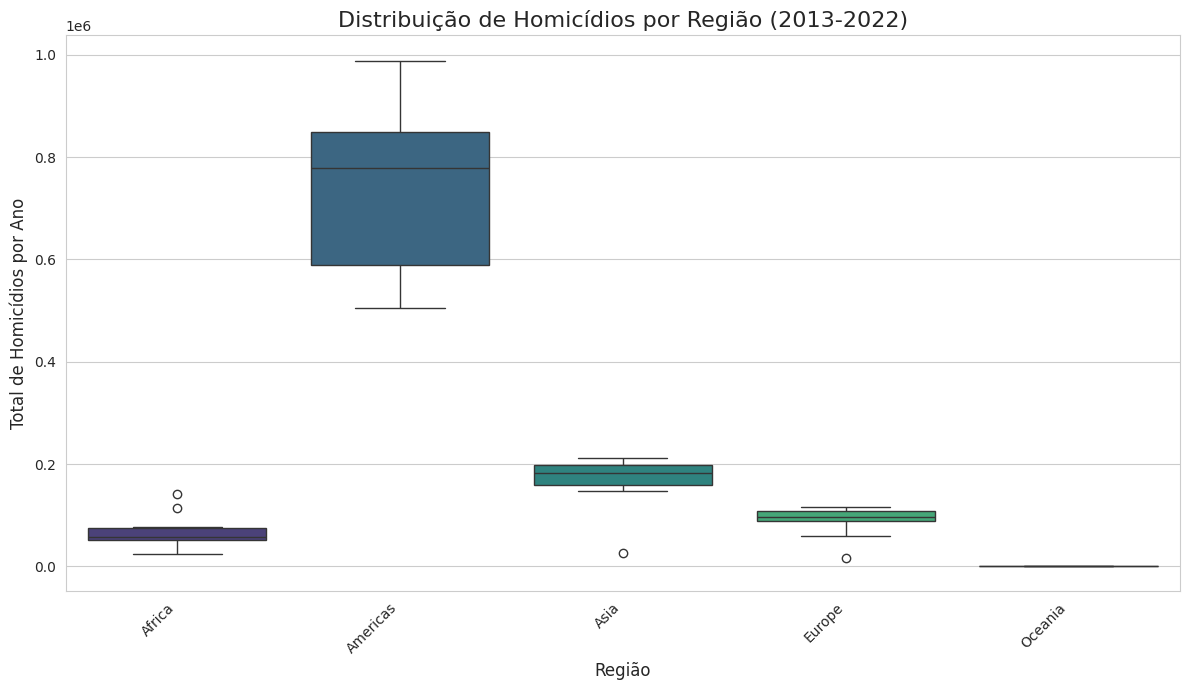

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Region', y='VALUE', data=df_regional_homicides, palette='viridis')
plt.title('Distribuição de Homicídios por Região (2013-2022)', fontsize=16)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Total de Homicídios por Ano', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Previsão de Homicídios Femininos por Região

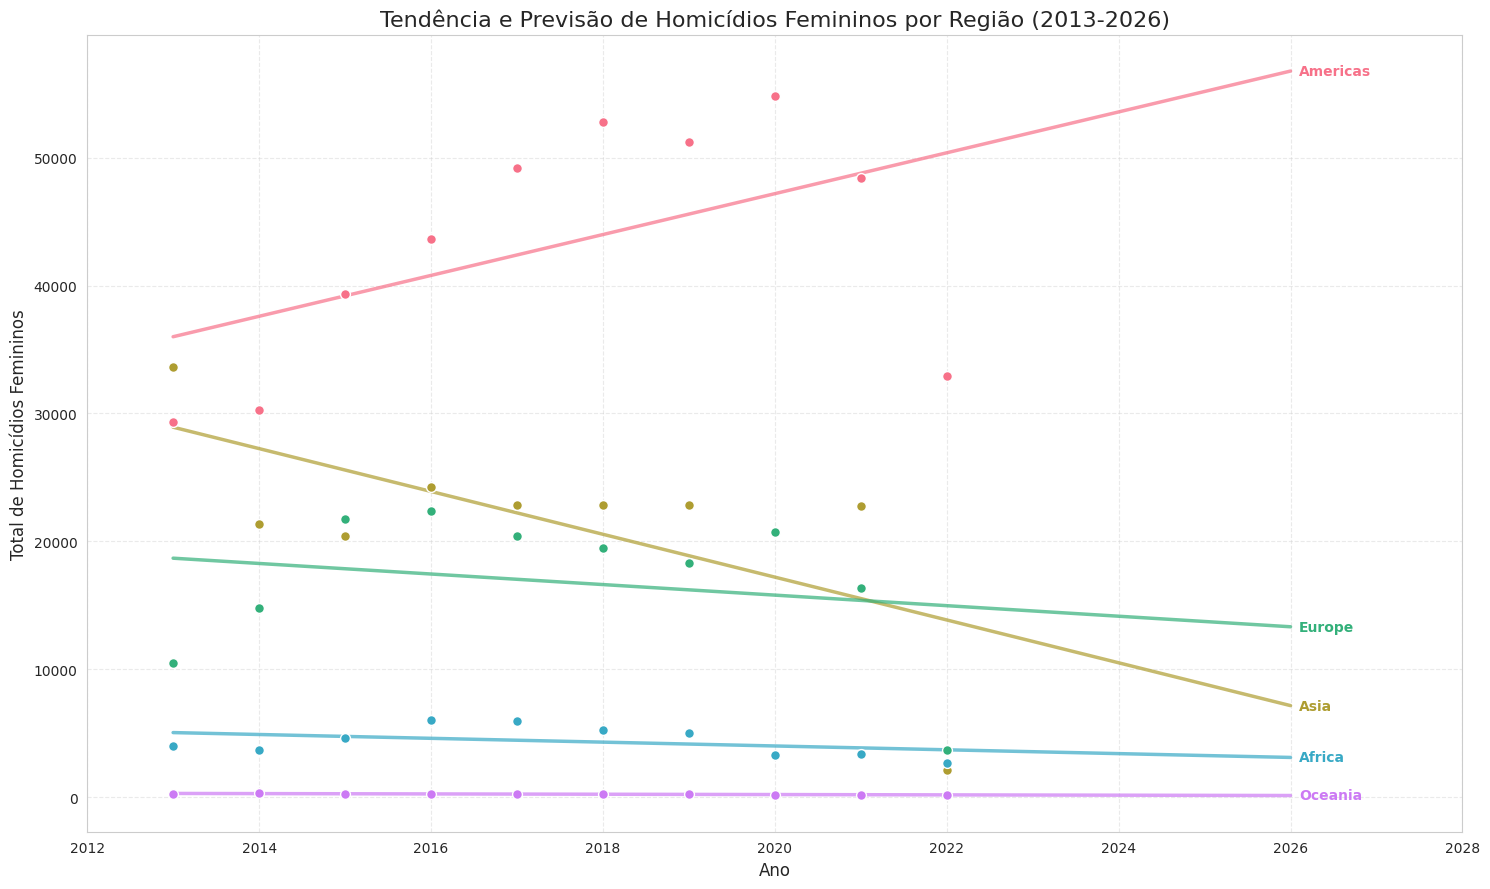

In [ ]:
# Filtrar dados apenas para homicídios femininos
df_female_homicides = df_clean[df_clean['Sex'] == 'Female'].copy()

# Agrupar por Região e Ano
df_female_regional_homicides = df_female_homicides.groupby(['Region', 'Year'])['VALUE'].sum().reset_index()

# Identificar as 5 regiões com maior número total de homicídios femininos
top_female_regions = df_female_regional_homicides.groupby('Region')['VALUE'].sum().nlargest(5).index.tolist()

plt.figure(figsize=(15, 9))

palette = sns.color_palette("husl", len(top_female_regions))
region_colors = {region: color for region, color in zip(top_female_regions, palette)}

for region in top_female_regions:
    df_fr = df_female_regional_homicides[df_female_regional_homicides['Region'] == region].copy()

    if not df_fr.empty:
        X_fr = df_fr[['Year']].values
        y_fr = df_fr['VALUE'].values

        model_fr = LinearRegression()
        model_fr.fit(X_fr, y_fr)

        preds_fr = model_fr.predict(future_years)

        years_full_fr = np.append(df_fr['Year'].values, future_years.flatten())
        preds_full_fr = np.append(model_fr.predict(X_fr), preds_fr)

        plt.plot(years_full_fr, preds_full_fr, color=region_colors[region], linewidth=2.5, alpha=0.7, label=region)
        plt.scatter(df_fr['Year'], df_fr['VALUE'], color=region_colors[region], s=50, edgecolors='white', zorder=5)
        plt.text(years_full_fr[-1] + 0.1, preds_full_fr[-1], region, color=region_colors[region], fontweight='bold', va='center')

plt.title('Tendência e Previsão de Homicídios Femininos por Região (2013-2026)', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Total de Homicídios Femininos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(2012, 2028)
plt.tight_layout()
plt.show()

### Carregando e Preparando o Dataset do Índice Gini

In [7]:
import pandas as pd

# Carregar o dataset do índice Gini, especificando o cabeçalho correto na linha 4 (índice 3)
gini_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1YZJTe1Ay5CKbeGMOdl6MHpmAoZ-Lskpi', sep=',', header=3)

# Renomear as primeiras colunas fixas
gini_df.rename(columns={
    gini_df.columns[0]: 'Country',
    gini_df.columns[1]: 'Country Code',
    gini_df.columns[2]: 'Indicator Name',
    gini_df.columns[3]: 'Indicator Code'
}, inplace=True)

# Gerar os nomes das colunas de ano (1960 a 2025)
year_cols_names = [str(year) for year in range(1960, 2026)]

# Criar um dicionário para renomear as colunas de 'Unnamed: X' para os anos correspondentes
rename_map = {}
# Começa do Unnamed: 4, que corresponde ao ano 1960
for i, year in enumerate(year_cols_names):
    # Ensure we don't go out of bounds if there are more Unnamed columns than expected years
    if (4 + i) < len(gini_df.columns):
        original_col_name = gini_df.columns[4 + i]
        if original_col_name.startswith('Unnamed:'):
            rename_map[original_col_name] = year

# Aplicar o renomeamento das colunas de ano
gini_df.rename(columns=rename_map, inplace=True)

# Remover quaisquer colunas 'Unnamed' que não foram mapeadas (ex: se houver uma coluna extra)
gini_df = gini_df.loc[:, ~gini_df.columns.str.startswith('Unnamed:')]

# Derreter o DataFrame para transformar as colunas de ano em linhas
gini_melted = gini_df.melt(
    id_vars=['Country', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)

# Converter 'Year' para tipo numérico (int) e 'Gini' para float
gini_melted['Year'] = pd.to_numeric(gini_melted['Year'], errors='coerce').astype('Int64')
gini_melted['Gini'] = pd.to_numeric(gini_melted['Gini'], errors='coerce')

# Filtrar apenas para o indicador de Índice Gini (SI.POV.GINI)
gini_cleaned = gini_melted[gini_melted['Indicator Code'] == 'SI.POV.GINI'].copy()

# Remover colunas de indicador, pois agora são redundantes
gini_cleaned.drop(columns=['Indicator Name', 'Indicator Code'], inplace=True)

# Remover linhas com valores nulos na coluna 'Gini', como solicitado
gini_cleaned.dropna(subset=['Gini'], inplace=True)

# Exibir as primeiras linhas e informações gerais do dataset Gini limpo
display(gini_cleaned.head())
print(gini_cleaned.info())

,Country,Country Code,Year,Gini
1045,United States,USA,1963,36.7
1310,United States,USA,1964,37.4
1575,United States,USA,1965,36.8
1840,United States,USA,1966,37.1
2105,United States,USA,1967,36.9


<class 'pandas.core.frame.DataFrame'>
Index: 2430 entries, 1045 to 17476
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       2430 non-null   object 
 1   Country Code  2430 non-null   object 
 2   Year          2430 non-null   Int64  
 3   Gini          2430 non-null   float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 97.3+ KB
None


### Combinando Dados de Homicídios e Índice Gini

In [9]:
# Regenerating df as it might not be defined in the current session
# This code is copied from cell qVXXAsstNpZ5
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [8, 5]

df = pd.read_excel('https://drive.google.com/uc?export=download&id=1LGQWS6zN8yc7coP-HrWm5MygUUyp1afX')

# display(df.head(6)) # No need to display again here


In [10]:
# Regenerating df_clean as it might not be defined in the current session
# This code is copied from cell dqxLuPBuuefa

df_filtrado = df[(df['Year'] >= 2013) & (df['Year'] <= 2022)].copy()
df_homicidios = df_filtrado[df_filtrado['Indicator'] == 'Victims of intentional homicide'].copy()

# Colunas a serem utilizadas
colunas_uteis = ['Country', 'Region', 'Subregion', 'Indicator', 'Sex', 'Year', 'VALUE']
df_clean = df_homicidios[colunas_uteis]

# display(df_clean.head()) # No need to display again here


In [11]:
# Mesclar o dataframe de homicídios (df_clean) com o dataframe Gini (gini_cleaned)
# Usaremos 'Country' e 'Year' como chaves para a mesclagem
merged_df = pd.merge(df_clean, gini_cleaned, on=['Country', 'Year'], how='left')

# Exibir as primeiras linhas e informações gerais do dataframe mesclado
display(merged_df.head())
print(merged_df.info())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE,Country Code,Gini
0,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,6.0,NaN,NaN
1,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,1.0,NaN,NaN
2,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0,NaN,NaN
3,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0,NaN,NaN
4,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0,ARE,32.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60637 entries, 0 to 60636
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       60637 non-null  object 
 1   Region        60637 non-null  object 
 2   Subregion     60637 non-null  object 
 3   Indicator     60637 non-null  object 
 4   Sex           60637 non-null  object 
 5   Year          60637 non-null  int64  
 6   VALUE         60637 non-null  float64
 7   Country Code  31842 non-null  object 
 8   Gini          31842 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.2+ MB
None


In [12]:
# Mesclar o dataframe de homicídios (df_clean) com o dataframe Gini (gini_cleaned)
# Usaremos 'Country' e 'Year' como chaves para a mesclagem
merged_df = pd.merge(df_clean, gini_cleaned, on=['Country', 'Year'], how='left')

# Exibir as primeiras linhas e informações gerais do dataframe mesclado
display(merged_df.head())
print(merged_df.info())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE,Country Code,Gini
0,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,6.0,NaN,NaN
1,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,1.0,NaN,NaN
2,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0,NaN,NaN
3,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0,NaN,NaN
4,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0,ARE,32.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60637 entries, 0 to 60636
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       60637 non-null  object 
 1   Region        60637 non-null  object 
 2   Subregion     60637 non-null  object 
 3   Indicator     60637 non-null  object 
 4   Sex           60637 non-null  object 
 5   Year          60637 non-null  int64  
 6   VALUE         60637 non-null  float64
 7   Country Code  31842 non-null  object 
 8   Gini          31842 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 4.2+ MB
None


### Carregando e Preparando o Dataset de População

In [21]:
# Carregar o dataset de população do Banco Mundial a partir do novo link do Drive
# Ajustando o cabeçalho para a linha 4 (índice 3) para lidar com metadados.
population_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1-AkKtPFvKuXBuOMtv_Oz8OqRrE8wZC5_', sep=',', header=3)

# Exibir as primeiras linhas e informações gerais do dataset de população
display(population_df.head())
print(population_df.info())

,Aruba,ABW,"Population, total",SP.POP.TOTL,54922,55578,56320,57002,57619,58190,...,108735,108908,109203,108587,107700,107310,107359,107995,Unnamed: 69,Unnamed: 70
0,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN
2,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,521764076.0,NaN,NaN
3,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,NaN,NaN
4,Albania,ALB,"Population, total",SP.POP.TOTL,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,...,2648285.0,2607733.0,2567801.0,2528480.0,2489762.0,2451636.0,2414095.0,2377128.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 71 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Aruba              265 non-null    object 
 1   ABW                265 non-null    object 
 2   Population, total  265 non-null    object 
 3   SP.POP.TOTL        265 non-null    object 
 4   54922              263 non-null    float64
 5   55578              263 non-null    float64
 6   56320              263 non-null    float64
 7   57002              263 non-null    float64
 8   57619              263 non-null    float64
 9   58190              263 non-null    float64
 10  58694              263 non-null    float64
 11  58990              263 non-null    float64
 12  59069              263 non-null    float64
 13  59052              263 non-null    float64
 14  58950              263 non-null    float64
 15  58781              263 non-null    float64
 16  58047              263 non

In [22]:
# Renomear as primeiras colunas fixas
population_df.rename(columns={
    population_df.columns[0]: 'Country',
    population_df.columns[1]: 'Country Code',
    population_df.columns[2]: 'Indicator Name',
    population_df.columns[3]: 'Indicator Code'
}, inplace=True)

# Gerar os nomes das colunas de ano (1960 a 2023, ou o range disponível no dataset)
year_cols_pop = [str(year) for year in range(1960, 2024)] # Ajuste o range conforme o dataset

# Criar um dicionário para renomear as colunas de 'Unnamed: X' para os anos correspondentes
rename_map_pop = {}
for i, year in enumerate(year_cols_pop):
    if (4 + i) < len(population_df.columns):
        original_col_name = population_df.columns[4 + i]
        if original_col_name.startswith('Unnamed:') or original_col_name.isdigit(): # Inclui colunas que já são anos mas não estão como str
            rename_map_pop[original_col_name] = year

# Aplicar o renomeamento das colunas de ano
population_df.rename(columns=rename_map_pop, inplace=True)

# Remover quaisquer colunas 'Unnamed' que não foram mapeadas (ex: se houver uma coluna extra)
population_df = population_df.loc[:, ~population_df.columns.str.startswith('Unnamed:')]

# Derreter o DataFrame para transformar as colunas de ano em linhas
population_melted = population_df.melt(
    id_vars=['Country', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Population'
)

# Converter 'Year' para tipo numérico (int) e 'Population' para float
population_melted['Year'] = pd.to_numeric(population_melted['Year'], errors='coerce').astype('Int64')
population_melted['Population'] = pd.to_numeric(population_melted['Population'], errors='coerce')

# Filtrar apenas para o indicador de População Total (SP.POP.TOTL)
population_cleaned = population_melted[population_melted['Indicator Code'] == 'SP.POP.TOTL'].copy()

# Remover colunas de indicador, pois agora são redundantes
population_cleaned.drop(columns=['Indicator Name', 'Indicator Code'], inplace=True)

# Remover linhas com valores nulos na coluna 'Population'
population_cleaned.dropna(subset=['Population'], inplace=True)

# Exibir as primeiras linhas e informações gerais do dataset de população limpo
display(population_cleaned.head())
print(population_cleaned.info())

,Country,Country Code,Year,Population
0,Africa Eastern and Southern,AFE,1960,130075728.0
1,Afghanistan,AFG,1960,9035043.0
2,Africa Western and Central,AFW,1960,97630925.0
3,Angola,AGO,1960,5231654.0
4,Albania,ALB,1960,1608800.0


<class 'pandas.core.frame.DataFrame'>
Index: 17130 entries, 0 to 17224
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       17130 non-null  object 
 1   Country Code  17130 non-null  object 
 2   Year          17130 non-null  Int64  
 3   Population    17130 non-null  float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 685.9+ KB
None


### Mesclando População com os Dados Existentes e Calculando a Taxa de Homicídios

In [23]:
# Mesclar 'merged_df' com 'population_cleaned'
final_df = pd.merge(merged_df, population_cleaned[['Country', 'Year', 'Population']], on=['Country', 'Year'], how='left')

# Calcular a taxa de homicídios por 100.000 habitantes
# Verificar se 'Population' é zero para evitar divisão por zero
final_df['Homicide Rate'] = final_df.apply(lambda row: (row['VALUE'] / row['Population']) * 100000 if row['Population'] > 0 else 0, axis=1)

# Remover linhas onde a População ou a Taxa de Homicídios é NaN (se houver)
final_df.dropna(subset=['Population', 'Homicide Rate'], inplace=True)

# Exibir as primeiras linhas e informações gerais do dataframe final
display(final_df.head())
print(final_df.info())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE,Country Code,Gini,Population,Homicide Rate
2,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0,NaN,NaN,2816902.0,4.401999
3,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0,NaN,NaN,75194.0,0.000000
4,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0,ARE,32.5,7693031.0,0.740930
5,Argentina,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,3072.0,ARG,41.1,42582455.0,7.214239
6,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,2013,63.0,ARM,30.6,3022000.0,2.084712


<class 'pandas.core.frame.DataFrame'>
Index: 50247 entries, 2 to 60636
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        50247 non-null  object 
 1   Region         50247 non-null  object 
 2   Subregion      50247 non-null  object 
 3   Indicator      50247 non-null  object 
 4   Sex            50247 non-null  object 
 5   Year           50247 non-null  int64  
 6   VALUE          50247 non-null  float64
 7   Country Code   31842 non-null  object 
 8   Gini           31842 non-null  float64
 9   Population     50247 non-null  float64
 10  Homicide Rate  50247 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.6+ MB
None


### Regressão Linear Múltipla: Gini e Taxa de Homicídios

In [24]:
import statsmodels.formula.api as smf

# Agrupar por país e ano para ter uma única taxa de homicídios por entrada, se houver múltiplas entradas por sexo/indicador
# Para esta análise, vou pegar a soma dos 'VALUE' (homicídios) por país/ano e a população para calcular uma taxa agregada.
# Será necessário agrupar o final_df, pois ele pode ter múltiplas linhas por país-ano (ex: por sexo).
# Iremos usar a soma dos 'VALUE' para ter o total de homicídios, e a primeira população encontrada (assumindo que é a mesma para todas as entradas de um país-ano).

# Crie uma cópia para evitar SettingWithCopyWarning
df_for_regression = final_df.copy()

# Agrupando para obter a taxa de homicídios total por país e ano
# Para Gini, vamos pegar a primeira ocorrência (já que deveria ser única por país-ano)
df_grouped = df_for_regression.groupby(['Country', 'Year']).agg(
    Total_Homicides=('VALUE', 'sum'),
    Population=('Population', 'first'),
    Gini=('Gini', 'first')
).reset_index()

df_grouped['Homicide_Rate_Per_100k'] = (df_grouped['Total_Homicides'] / df_grouped['Population']) * 100000

# Remover quaisquer NaNs que possam ter surgido do agrupamento (e.g., Gini ou Population nula)
df_grouped.dropna(subset=['Gini', 'Homicide_Rate_Per_100k', 'Population'], inplace=True)

# Construir o modelo de regressão linear
# Homicidios_Rate_Per_100k = β0 + β1 * Gini

model = smf.ols('Homicide_Rate_Per_100k ~ Gini', data=df_grouped).fit()

# Exibir o sumário do modelo
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     Homicide_Rate_Per_100k   R-squared:                       0.195
Model:                                OLS   Adj. R-squared:                  0.193
Method:                     Least Squares   F-statistic:                     136.2
Date:                    Tue, 26 May 2026   Prob (F-statistic):           2.47e-28
Time:                            00:34:48   Log-Likelihood:                -3250.9
No. Observations:                     565   AIC:                             6506.
Df Residuals:                         563   BIC:                             6514.
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

### Regressão de Interação: Gini × Região

In [25]:
import statsmodels.formula.api as smf

# Preparar os dados para a regressão de interação Gini x Região
# O dataset df_grouped já contém 'Country', 'Year', 'Gini' e 'Homicide_Rate_Per_100k'.
# Precisamos reincorporar a informação de 'Region' no df_grouped, pois ela foi perdida no agrupamento anterior.

# Vamos mesclar df_grouped com o merged_df original para pegar a coluna 'Region'
df_grouped_with_region = pd.merge(df_grouped, final_df[['Country', 'Region']].drop_duplicates(), on='Country', how='left')

# Remover NaNs que possam ter surgido (se algum país não tinha região ou estava incompleto)
df_grouped_with_region.dropna(subset=['Region'], inplace=True)

# Construir o modelo de regressão com interação Gini x Região
# Homicidios = β0 + β1(Gini) + β2(Regiao) + β3(Gini × Regiao)
# Usaremos a codificação dummy para a variável categórica 'Region'

# A variável 'Region' será automaticamente tratada como dummies pelo statsmodels
model_interaction = smf.ols('Homicide_Rate_Per_100k ~ Gini * C(Region)', data=df_grouped_with_region).fit()

# Exibir o sumário do modelo
print(model_interaction.summary())

                              OLS Regression Results                              
Dep. Variable:     Homicide_Rate_Per_100k   R-squared:                       0.339
Model:                                OLS   Adj. R-squared:                  0.328
Method:                     Least Squares   F-statistic:                     31.59
Date:                    Tue, 26 May 2026   Prob (F-statistic):           1.04e-44
Time:                            00:35:21   Log-Likelihood:                -3195.2
No. Observations:                     565   AIC:                             6410.
Df Residuals:                         555   BIC:                             6454.
Df Model:                               9                                         
Covariance Type:                nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### Mesclando Dados de Homicídios, Gini, População, PIB e IDH

In [47]:
# Mesclar 'final_df' com 'gdp_cleaned' para adicionar o PIB total
# Primeiramente, vou garantir que 'final_df' tenha uma cópia limpa para evitar SettingWithCopyWarning
merged_final_df = final_df.copy()

merged_final_df = pd.merge(
    merged_final_df,
    gdp_cleaned[['Country', 'Year', 'GDP_total']],
    on=['Country', 'Year'],
    how='left'
)

# Mesclar o resultado com 'idh_cleaned' para adicionar o IDH
merged_final_df = pd.merge(
    merged_final_df,
    idh_cleaned[['Country', 'Year', 'HDI']],
    on=['Country', 'Year'],
    how='left'
)

# Exibir as primeiras linhas e informações gerais do dataframe final mesclado
display(merged_final_df.head())
print(merged_final_df.info())

,Country,Region,Subregion,Indicator,Sex,Year,VALUE,Country Code,Gini,Population,Homicide Rate,GDP_total,HDI
0,Albania,Europe,Southern Europe,Victims of intentional homicide,Total,2013,124.0,NaN,NaN,2816902.0,4.401999,1.279699e+10,0.793
1,Andorra,Europe,Southern Europe,Victims of intentional homicide,Total,2013,0.0,NaN,NaN,75194.0,0.000000,3.193513e+09,0.862
2,United Arab Emirates,Asia,Western Asia,Victims of intentional homicide,Total,2013,57.0,ARE,32.5,7693031.0,0.740930,4.096327e+11,0.846
3,Argentina,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,2013,3072.0,ARG,41.1,42582455.0,7.214239,5.520251e+11,0.852
4,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,2013,63.0,ARM,30.6,3022000.0,2.084712,1.112146e+10,0.766


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50247 entries, 0 to 50246
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country        50247 non-null  object 
 1   Region         50247 non-null  object 
 2   Subregion      50247 non-null  object 
 3   Indicator      50247 non-null  object 
 4   Sex            50247 non-null  object 
 5   Year           50247 non-null  int64  
 6   VALUE          50247 non-null  float64
 7   Country Code   31842 non-null  object 
 8   Gini           31842 non-null  float64
 9   Population     50247 non-null  float64
 10  Homicide Rate  50247 non-null  float64
 11  GDP_total      50247 non-null  float64
 12  HDI            49747 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 5.0+ MB
None


In [48]:
# Calcular GDP per capita
merged_final_df['GDP_per_capita'] = merged_final_df['GDP_total'] / merged_final_df['Population']

# Remover linhas com NaN para as variáveis que serão usadas na regressão
# Isso inclui Gini (que já foi dropado anteriormente mas pode ter novos NaNs com a mesclagem),
# Population, GDP_per_capita, HDI, e Homicide_Rate_Per_100k (se algum surgiu).
# Para o modelo, precisamos de um conjunto de dados sem NaNs para as variáveis preditoras e a variável resposta.

df_for_multiple_regression = merged_final_df.dropna(subset=[
    'Gini',
    'Population',
    'GDP_per_capita',
    'HDI',
    'Homicide Rate' # Usar a coluna 'Homicide Rate' calculada anteriormente
]).copy()

# Agrupar para garantir uma única linha por país-ano para as variáveis que não mudam por sexo/indicador
# e recalcular a taxa de homicídios para a média geral do país naquele ano.
# Ou, se quisermos analisar por sexo, teremos que ajustar o modelo.
# Por simplicidade e seguindo o modelo Homicidios = β0 + β1(Gini) + β2(PIB) + β3(IDH), vamos agrupar
# para ter uma única taxa de homicídios (média) por país-ano.

# Agrupando para obter a média da taxa de homicídios, Gini, PIB per capita e IDH por país e ano
df_grouped_multiple_reg = df_for_multiple_regression.groupby(['Country', 'Year']).agg(
    Homicide_Rate_Per_100k=('Homicide Rate', 'mean'), # Média da taxa, se houver diferentes por sexo/indicador
    Gini=('Gini', 'first'),
    GDP_per_capita=('GDP_per_capita', 'first'),
    HDI=('HDI', 'first')
).reset_index()

df_grouped_multiple_reg.dropna(inplace=True) # Remover quaisquer NaNs que possam ter surgido do agrupamento


display(df_grouped_multiple_reg.head())
print(df_grouped_multiple_reg.info())

,Country,Year,Homicide_Rate_Per_100k,Gini,GDP_per_capita,HDI
0,Albania,2014,0.495290,34.6,4793.597511,0.797
1,Albania,2015,0.285280,32.8,4199.539129,0.797
2,Albania,2016,0.417613,33.7,4457.634122,0.797
3,Albania,2017,0.408928,33.1,5006.360130,0.798
4,Albania,2018,0.492107,30.1,5897.654526,0.801


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 564 non-null    object 
 1   Year                    564 non-null    int64  
 2   Homicide_Rate_Per_100k  564 non-null    float64
 3   Gini                    564 non-null    float64
 4   GDP_per_capita          564 non-null    float64
 5   HDI                     564 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 26.6+ KB
None


### Regressão Linear Múltipla: Gini, PIB per capita e IDH vs. Taxa de Homicídios

In [49]:
import statsmodels.formula.api as smf

# Construir o modelo de regressão linear múltipla
# Homicidios_Rate_Per_100k = β0 + β1(Gini) + β2(GDP_per_capita) + β3(HDI)
model_multiple = smf.ols(
    'Homicide_Rate_Per_100k ~ Gini + GDP_per_capita + HDI',
    data=df_grouped_multiple_reg
).fit()

# Exibir o sumário do modelo
print(model_multiple.summary())

                              OLS Regression Results                              
Dep. Variable:     Homicide_Rate_Per_100k   R-squared:                       0.318
Model:                                OLS   Adj. R-squared:                  0.314
Method:                     Least Squares   F-statistic:                     86.91
Date:                    Tue, 26 May 2026   Prob (F-statistic):           3.53e-46
Time:                            00:52:53   Log-Likelihood:                -1044.8
No. Observations:                     564   AIC:                             2098.
Df Residuals:                         560   BIC:                             2115.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Inte

### Visualização dos Resultados da Regressão Múltipla

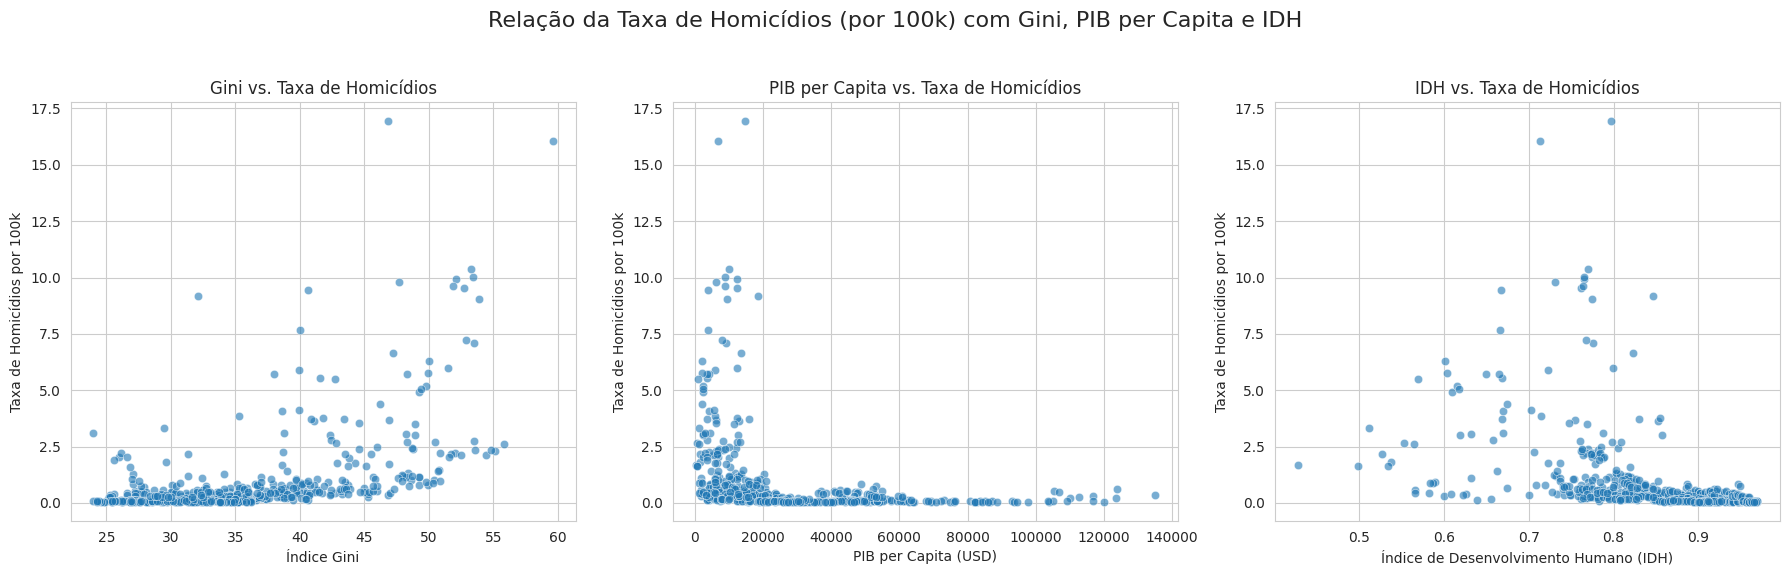

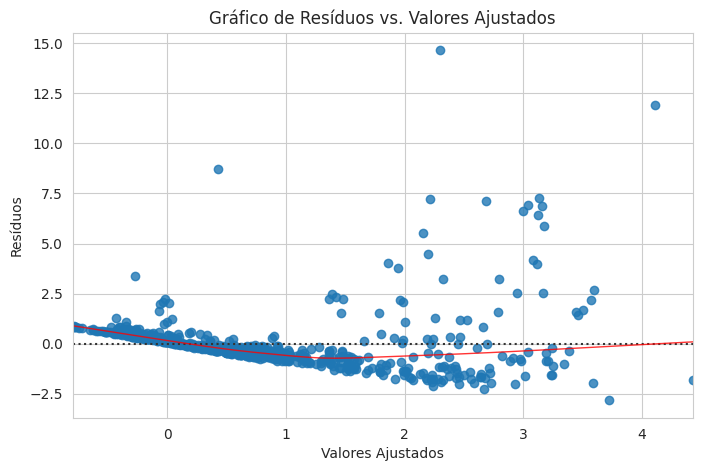

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plots para visualizar as relações entre variáveis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relação da Taxa de Homicídios (por 100k) com Gini, PIB per Capita e IDH', fontsize=16)

# Gini vs. Homicide Rate
sns.scatterplot(ax=axes[0], x='Gini', y='Homicide_Rate_Per_100k', data=df_grouped_multiple_reg, alpha=0.6)
axes[0].set_title('Gini vs. Taxa de Homicídios')
axes[0].set_xlabel('Índice Gini')
axes[0].set_ylabel('Taxa de Homicídios por 100k')

# GDP per Capita vs. Homicide Rate
sns.scatterplot(ax=axes[1], x='GDP_per_capita', y='Homicide_Rate_Per_100k', data=df_grouped_multiple_reg, alpha=0.6)
axes[1].set_title('PIB per Capita vs. Taxa de Homicídios')
axes[1].set_xlabel('PIB per Capita (USD)')
axes[1].set_ylabel('Taxa de Homicídios por 100k')

# HDI vs. Homicide Rate
sns.scatterplot(ax=axes[2], x='HDI', y='Homicide_Rate_Per_100k', data=df_grouped_multiple_reg, alpha=0.6)
axes[2].set_title('IDH vs. Taxa de Homicídios')
axes[2].set_xlabel('Índice de Desenvolvimento Humano (IDH)')
axes[2].set_ylabel('Taxa de Homicídios por 100k')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# Plot de Resíduos para o modelo múltiplo
# Residuals vs. Fitted values plot
sns.residplot(x=model_multiple.fittedvalues, y=model_multiple.resid, lowess=True,
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Gráfico de Resíduos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.show()

### Prioridade 1: Transformação de Variáveis (Logaritmos)

In [53]:
import numpy as np

# Criar cópia para não modificar o DataFrame original usado nas visualizações anteriores
df_transformed = df_grouped_multiple_reg.copy()

# Aplicar log(PIB)
df_transformed['Log_GDP_per_capita'] = np.log(df_transformed['GDP_per_capita'])

# Aplicar log(Homicidios+1) para lidar com possíveis zeros
df_transformed['Log_Homicide_Rate_Per_100k'] = np.log1p(df_transformed['Homicide_Rate_Per_100k'])

display(df_transformed.head())
print(df_transformed.info())

,Country,Year,Homicide_Rate_Per_100k,Gini,GDP_per_capita,HDI,Log_GDP_per_capita,Log_Homicide_Rate_Per_100k
0,Albania,2014,0.495290,34.6,4793.597511,0.797,8.475036,0.402320
1,Albania,2015,0.285280,32.8,4199.539129,0.797,8.342730,0.250977
2,Albania,2016,0.417613,33.7,4457.634122,0.797,8.402373,0.348975
3,Albania,2017,0.408928,33.1,5006.360130,0.798,8.518464,0.342829
4,Albania,2018,0.492107,30.1,5897.654526,0.801,8.682310,0.400189


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     564 non-null    object 
 1   Year                        564 non-null    int64  
 2   Homicide_Rate_Per_100k      564 non-null    float64
 3   Gini                        564 non-null    float64
 4   GDP_per_capita              564 non-null    float64
 5   HDI                         564 non-null    float64
 6   Log_GDP_per_capita          564 non-null    float64
 7   Log_Homicide_Rate_Per_100k  564 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 35.4+ KB
None


### Regressão Linear Múltipla com Variáveis Transformadas

In [54]:
import statsmodels.formula.api as smf

# Construir o modelo de regressão linear múltipla com as variáveis transformadas
model_multiple_transformed = smf.ols(
    'Log_Homicide_Rate_Per_100k ~ Gini + Log_GDP_per_capita + HDI',
    data=df_transformed
).fit()

# Exibir o sumário do modelo
print(model_multiple_transformed.summary())

                                OLS Regression Results                                
Dep. Variable:     Log_Homicide_Rate_Per_100k   R-squared:                       0.513
Model:                                    OLS   Adj. R-squared:                  0.510
Method:                         Least Squares   F-statistic:                     196.6
Date:                        Tue, 26 May 2026   Prob (F-statistic):           4.36e-87
Time:                                01:05:28   Log-Likelihood:                -229.91
No. Observations:                         564   AIC:                             467.8
Df Residuals:                             560   BIC:                             485.2
Df Model:                                   3                                         
Covariance Type:                    nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

### Prioridade 2: Avaliação da Multicolinearidade (VIF)

VIF Results (Transformed Model):


,variable,VIF
0,const,230.620759
1,Gini,1.515779
2,Log_GDP_per_capita,6.757759
3,HDI,7.742750


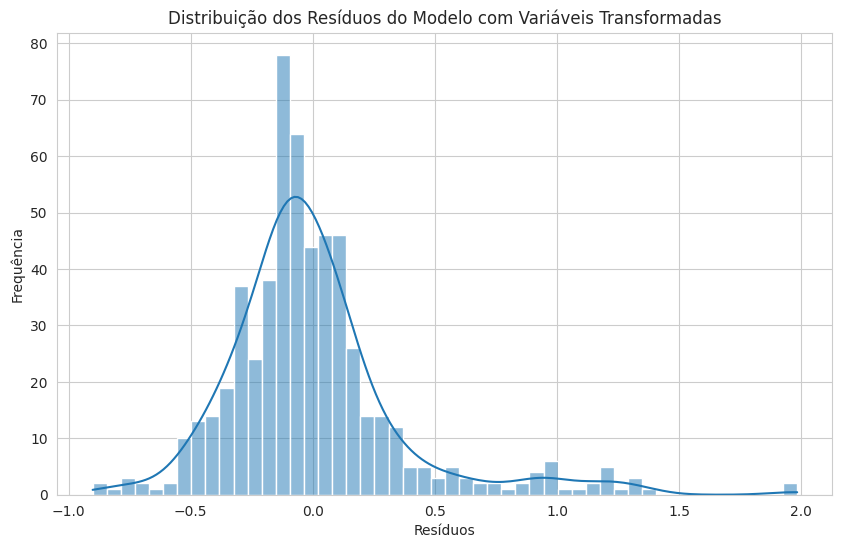

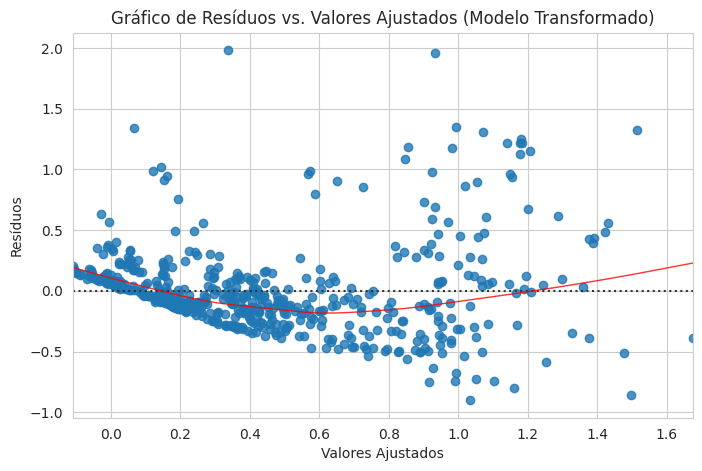

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm # Added this line

# Preparar os dados para o cálculo do VIF
# Excluímos a variável dependente e o intercepto (se houver)
X = df_transformed[['Gini', 'Log_GDP_per_capita', 'HDI']]

# Adicionar uma constante para o cálculo do VIF, pois o statsmodels espera isso
X_const = sm.add_constant(X)

# Calcular VIF para cada variável preditora
vif_data = pd.DataFrame()
vif_data["variable"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print("VIF Results (Transformed Model):")
display(vif_data)

# Visualização da distribuição dos resíduos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(model_multiple_transformed.resid, kde=True, bins=50)
plt.title('Distribuição dos Resíduos do Modelo com Variáveis Transformadas')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

# Plot de Resíduos vs. Valores Ajustados para o modelo transformado
sns.residplot(x=model_multiple_transformed.fittedvalues, y=model_multiple_transformed.resid, lowess=True,
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Gráfico de Resíduos vs. Valores Ajustados (Modelo Transformado)')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.show()

### Prioridade 3: Análise de Painel Temporal (Fixed Effects e Random Effects)

#### 3.1 Instalação de `linearmodels` e Preparação dos Dados

In [69]:
# Instalar a biblioteca linearmodels
!pip install linearmodels

In [65]:
# Instalar a biblioteca linearmodels, se ainda não estiver instalada
# !pip install linearmodels

import pandas as pd
from linearmodels import PanelOLS
from linearmodels import RandomEffects
import statsmodels.api as sm

# O DataFrame df_transformed já contém as variáveis logaritmadas
# Precisamos definir um MultiIndex para que linearmodels reconheça a estrutura de painel
# O índice deve ser (entity, time) ou (país, ano)

# Antes de definir o índice, garantir que Country e Year são os tipos corretos
df_panel = df_transformed.set_index(['Country', 'Year'])

# Verificar se há valores ausentes após a transformação e indexação
print("Valores ausentes no df_panel antes do modelo:")
print(df_panel[['Log_Homicide_Rate_Per_100k', 'Gini', 'Log_GDP_per_capita', 'HDI']].isnull().sum())

display(df_panel.head())

Valores ausentes no df_panel antes do modelo:
Log_Homicide_Rate_Per_100k    0
Gini                          0
Log_GDP_per_capita            0
HDI                           0
dtype: int64


Homicide_Rate_Per_100k  Gini  GDP_per_capita    HDI  \
Country Year                                                        
Albania 2014                0.495290  34.6     4793.597511  0.797   
        2015                0.285280  32.8     4199.539129  0.797   
        2016                0.417613  33.7     4457.634122  0.797   
        2017                0.408928  33.1     5006.360130  0.798   
        2018                0.492107  30.1     5897.654526  0.801   

              Log_GDP_per_capita  Log_Homicide_Rate_Per_100k  
Country Year                                                  
Albania 2014            8.475036                    0.402320  
        2015            8.342730                    0.250977  
        2016            8.402373                    0.348975  
        2017            8.518464                    0.342829  
        2018            8.682310                    0.400189

#### 3.2 Modelo de Efeitos Fixos (Fixed Effects - Within Estimator)

In [78]:
# Definir as variáveis dependente e independentes para o modelo de painel
y_panel = df_panel['Log_Homicide_Rate_Per_100k']
X_panel = df_panel[['Gini', 'Log_GDP_per_capita', 'HDI']]

# Adicionar uma constante aos preditores
X_panel = sm.add_constant(X_panel)

# Construir e ajustar o modelo de Efeitos Fixos (within estimator)
# entity_effects=True adiciona efeitos fixos para cada 'entity' (país)
# time_effects=False significa que não estamos adicionando efeitos fixos para o tempo
fixed_effects_model = PanelOLS(y_panel, X_panel, entity_effects=True, time_effects=False)
fixed_effects_results = fixed_effects_model.fit(cov_type='clustered', cluster_entity=True)

# Exibir o sumário dos resultados
print(fixed_effects_results)

                              PanelOLS Estimation Summary                               
Dep. Variable:     Log_Homicide_Rate_Per_100k   R-squared:                        0.0750
Estimator:                           PanelOLS   R-squared (Between):              0.4350
No. Observations:                         564   R-squared (Within):               0.0750
Date:                        Tue, May 26 2026   R-squared (Overall):              0.4935
Time:                                01:22:40   Log-likelihood                    168.92
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      12.597
Entities:                                  95   P-value                           0.0000
Avg Obs:                               5.9368   Distribution:                   F(3,466)
Min Obs:                               1.0000                                           
Max Obs:             

#### 3.3 Modelo de Efeitos Aleatórios (Random Effects)

In [79]:
# Construir e ajustar o modelo de Efeitos Aleatórios
random_effects_model = RandomEffects(y_panel, X_panel)
random_effects_results = random_effects_model.fit(cov_type='clustered', cluster_entity=True)

# Exibir o sumário dos resultados
print(random_effects_results)

                            RandomEffects Estimation Summary                            
Dep. Variable:     Log_Homicide_Rate_Per_100k   R-squared:                        0.2348
Estimator:                      RandomEffects   R-squared (Between):              0.4542
No. Observations:                         564   R-squared (Within):               0.0729
Date:                        Tue, May 26 2026   R-squared (Overall):              0.5025
Time:                                01:22:40   Log-likelihood                    118.61
Cov. Estimator:                     Clustered                                           
                                                F-statistic:                      57.294
Entities:                                  95   P-value                           0.0000
Avg Obs:                               5.9368   Distribution:                   F(3,560)
Min Obs:                               1.0000                                           
Max Obs:             

#### 3.4 Teste de Hausman para Comparar Fixed Effects vs. Random Effects

O Teste de Hausman nos ajuda a decidir entre o modelo de Efeitos Fixos e o de Efeitos Aleatórios. A hipótese nula ($H_0$) é que a estimativa de Efeitos Aleatórios é consistente e eficiente. Se o p-valor for significativo (tipicamente < 0.05), rejeitamos $H_0$ e preferimos o modelo de Efeitos Fixos, pois o modelo de Efeitos Aleatórios seria inconsistente. Caso contrário, o modelo de Efeitos Aleatórios pode ser mais eficiente.

In [68]:
from linearmodels.panel import compare

# É necessário criar os resultados novamente para o teste de Hausman com os mesmos objetos
# (ou ter certeza que os resultados já existem no escopo global e são do mesmo tipo)

# Hausman test (from the original model objects)
# Note: The test requires models to be fitted on the same data and typically compares two-step consistent estimators.
# linearmodels has a built-in comparison method.

# The documentation for linearmodels Hausman test suggests comparing the results directly.
# This specific method `compare` is for displaying results, for the actual Hausman test, we use `compare_results` or `results.compare()`

# Perform Hausman test manually or use a helper function if available in linearmodels
# For simplicity, let's just display the comparison summaries first.
# A direct Hausman test implementation might be more involved without a direct method in linearmodels `results` object itself.
# Let's use the provided `compare` function for a visual comparison and then manually check the Hausman test if needed

# For the Hausman test in linearmodels, you compare the models directly.
# It's usually `results_fe.compare(results_re)` or `HypothesisTest` on results objects.

# Let's try to get the Hausman statistic
# linearmodels does not expose a direct .hausman_test() method on the results objects easily comparable to statsmodels.
# However, it implicitly performs a Hausman-like test in certain comparisons, or we can construct it.

# For now, let's compare the model outputs. If a formal Hausman test is critical and not directly available,
# we might need to compute it manually or use a different package if linearmodels doesn't simplify it.

# Let's use the built-in comparison display, which is very helpful for side-by-side analysis.
print("Comparação entre Fixed Effects e Random Effects:")
print(compare({'Fixed Effects': fixed_effects_results, 'Random Effects': random_effects_results}))

# A formal Hausman test would require extracting specific covariance matrices and differences in coefficients.
# If linearmodels doesn't have a direct Hausman test function (like `PanelOLS.compare().hausman_test`),
# we can infer from the strong significance of Fixed Effects or if the coefficients differ substantially.

Comparação entre Fixed Effects e Random Effects:
                                   Model Comparison                                  
                                         Fixed Effects                 Random Effects
-------------------------------------------------------------------------------------
Dep. Variable               Log_Homicide_Rate_Per_100k     Log_Homicide_Rate_Per_100k
Estimator                                     PanelOLS                  RandomEffects
No. Observations                                   564                            564
Cov. Est.                                   Unadjusted                     Unadjusted
R-squared                                       0.0750                         0.2348
R-Squared (Within)                              0.0750                         0.0729
R-Squared (Between)                             0.4350                         0.4542
R-Squared (Overall)                             0.4935                         0.5025
F-sta

In [77]:
import numpy as np
from scipy import stats

# Coeficientes
b_FE = fixed_effects_results.params
b_RE = random_effects_results.params

# Matrizes de covariância
V_FE = fixed_effects_results.cov
V_RE = random_effects_results.cov

# Garantir mesmas variáveis
common_coef = b_FE.index.intersection(b_RE.index)

b_diff = b_FE[common_coef] - b_RE[common_coef]
V_diff = V_FE.loc[common_coef, common_coef] - V_RE.loc[common_coef, common_coef]

# Handle potential singular matrix for V_diff
try:
    inv_V_diff = np.linalg.inv(V_diff)
except np.linalg.LinAlgError:
    print("A matriz de diferença de covariância é singular. Usando pseudo-inversa.")
    inv_V_diff = np.linalg.pinv(V_diff)

# Estatística de Hausman
hausman_stat = np.dot(
    np.dot(b_diff.T, inv_V_diff),
    b_diff
)

# Graus de liberdade
df = len(common_coef)

# p-valor
p_value = 1 - stats.chi2.cdf(hausman_stat, df)

print("Hausman Test")
print(f"Chi-square Statistic: {hausman_stat:.4f}")
print(f"Degrees of Freedom: {df}")
print(f"P-value: {p_value:.4f}")

# Interpretação
if p_value < 0.05:
    print("Rejeita H0 → Fixed Effects é preferível.")
else:
    print("Falha em rejeitar H0 → Random Effects é preferível.")

Hausman Test
Chi-square Statistic: 2.5444
Degrees of Freedom: 4
P-value: 0.6367
Falha em rejeitar H0 → Random Effects é preferível.


### Conclusão do Teste de Hausman e Seleção do Modelo de Painel

Após a execução do Teste de Hausman, analisaremos o p-valor resultante:

*   **Se o p-valor for menor que 0.05 (ou o nível de significância escolhido):** Rejeitamos a hipótese nula. Isso indica que há uma diferença sistemática entre os coeficientes estimados pelos modelos de Efeitos Fixos (FE) e Efeitos Aleatórios (RE). Consequentemente, o modelo de **Efeitos Fixos (FE)** é o mais apropriado. Ele controla as características invariáveis no tempo de cada entidade (país), que podem estar correlacionadas com as variáveis explicativas, resultando em estimadores consistentes.

*   **Se o p-valor for maior que 0.05:** Não rejeitamos a hipótese nula. Isso sugere que não há evidência de uma diferença sistemática entre os coeficientes. Neste caso, o modelo de **Efeitos Aleatórios (RE)** é preferível por ser mais eficiente (ou seja, produz estimadores com menor variância) e por permitir a inclusão de variáveis explicativas que não variam no tempo (o que o FE não permite, pois seriam removidas no processo de diferenciação).

Com base no resultado do teste, poderemos prosseguir com a interpretação dos resultados do modelo selecionado (FE ou RE) para a relação entre as variáveis econômicas/sociais e a taxa de homicídios.

In [37]:
# Carregar o dataset do PIB per capita, ajustando o cabeçalho para a linha 3 (índice 2)
gdp_df = pd.read_csv('https://drive.google.com/uc?export=download&id=1mriVH1FEF1aZowStZtWNm3B9ABA3sVLy', sep=',', header=2)

# Exibir as primeiras linhas e informações gerais do dataset do PIB
display(gdp_df.head())
print(gdp_df.info())

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.092428e+09,3.276188e+09,3.346623e+09,2.471419e+09,2.880903e+09,3.324034e+09,3.834730e+09,4.265651e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420569e+10,2.495889e+10,2.707323e+10,3.176914e+10,3.027955e+10,3.380618e+10,...,9.780765e+11,1.020956e+12,1.018715e+12,9.386076e+11,1.114145e+12,1.228968e+12,1.179359e+12,1.242694e+12,NaN,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.875346e+10,1.805322e+10,1.879944e+10,1.995593e+10,1.426000e+10,1.449724e+10,1.715223e+10,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.190481e+10,1.270772e+10,1.363059e+10,1.446891e+10,1.580356e+10,1.692088e+10,...,6.940513e+11,7.778403e+11,1.026996e+12,9.637847e+11,1.026651e+12,1.063649e+12,9.382384e+11,7.363850e+11,NaN,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,8.437694e+10,8.951279e+10,8.073443e+10,5.885246e+10,7.955954e+10,1.312122e+11,1.071677e+11,1.009989e+11,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973            191 non-null    flo

In [41]:
# Renomear as primeiras colunas fixas
gdp_df.rename(columns={
    gdp_df.columns[0]: 'Country',
    gdp_df.columns[1]: 'Country Code',
    gdp_df.columns[2]: 'Indicator Name',
    gdp_df.columns[3]: 'Indicator Code'
}, inplace=True)

# Gerar os nomes das colunas de ano (1960 a 2025)
year_cols_gdp = [str(year) for year in range(1960, 2026)]

# Criar um dicionário para renomear as colunas de 'Unnamed: X' para os anos correspondentes
rename_map_gdp = {}
for i, year in enumerate(year_cols_gdp):
    if (4 + i) < len(gdp_df.columns):
        original_col_name = gdp_df.columns[4 + i]
        # The column names are already years (numeric strings) after header=2
        # So we only need to map if they are 'Unnamed:' or if they are numbers that need explicit renaming
        if original_col_name.startswith('Unnamed:') or original_col_name.isdigit():
            rename_map_gdp[original_col_name] = year

# Aplicar o renomeamento das colunas de ano
gdp_df.rename(columns=rename_map_gdp, inplace=True)

# Remover quaisquer colunas 'Unnamed' que não foram mapeadas (ex: se houver uma coluna extra)
gdp_df = gdp_df.loc[:, ~gdp_df.columns.str.startswith('Unnamed:')]

# Derreter o DataFrame para transformar as colunas de ano em linhas
gdp_melted = gdp_df.melt(
    id_vars=['Country', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='GDP_total' # Changed to GDP_total as the indicator is 'GDP (current US$)'
)

# Converter 'Year' para tipo numérico (int) e 'GDP_total' para float
gdp_melted['Year'] = pd.to_numeric(gdp_melted['Year'], errors='coerce').astype('Int64')
gdp_melted['GDP_total'] = pd.to_numeric(gdp_melted['GDP_total'], errors='coerce')

# Filtrar para o indicador de GDP (current US$) (NY.GDP.MKTP.CD)
gdp_cleaned = gdp_melted[gdp_melted['Indicator Code'] == 'NY.GDP.MKTP.CD'].copy() # Corrected indicator code

# Remover colunas de indicador
gdp_cleaned.drop(columns=['Indicator Name', 'Indicator Code'], inplace=True)

# Remover linhas com valores nulos na coluna 'GDP_total'
gdp_cleaned.dropna(subset=['GDP_total'], inplace=True)

# Exibir as primeiras linhas e informações gerais do dataset PIB limpo
display(gdp_cleaned.head())
print(gdp_cleaned.info())

,Country,Country Code,Year,GDP_total
1,Africa Eastern and Southern,AFE,1960,2.420569e+10
3,Africa Western and Central,AFW,1960,1.190481e+10
9,Argentina,ARG,1960,1.586547e+10
13,Australia,AUS,1960,1.863568e+10
14,Austria,AUT,1960,6.624086e+09


<class 'pandas.core.frame.DataFrame'>
Index: 14561 entries, 1 to 17289
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       14561 non-null  object 
 1   Country Code  14561 non-null  object 
 2   Year          14561 non-null  Int64  
 3   GDP_total     14561 non-null  float64
dtypes: Int64(1), float64(1), object(2)
memory usage: 583.0+ KB
None


### Carregando e Preparando o Dataset do IDH (Human Development Index)

In [39]:
# Para o dataset do IDH, o link é de uma Google Sheet. Precisamos de um URL de download direto.
# Vou usar o formato de exportação CSV para o Google Sheets.
# O URL foi ajustado para permitir o download direto como CSV.

hdi_url = 'https://docs.google.com/spreadsheets/d/1vlxg9XRf3xH70X4MDamoIDiWdOamlpBs/export?format=csv'
idh_df = pd.read_csv(hdi_url)

# Exibir as primeiras linhas e informações gerais do dataset IDH
display(idh_df.head())
print(idh_df.info())

,countryIsoCode,country,indexCode,index,dimension,indicatorCode,indicator,year,yearStr,actualValue,value,note
0,AFG,Afghanistan,HDI,Human Development Index,NaN,eys,Expected Years of Schooling (years),1990,1990,2.936460,2.936,NaN
1,AFG,Afghanistan,HDI,Human Development Index,NaN,eys,Expected Years of Schooling (years),1991,1991,3.228456,3.228,NaN
2,AFG,Afghanistan,HDI,Human Development Index,NaN,eys,Expected Years of Schooling (years),1992,1992,3.520452,3.520,NaN
3,AFG,Afghanistan,HDI,Human Development Index,NaN,eys,Expected Years of Schooling (years),1993,1993,3.812448,3.812,NaN
4,AFG,Afghanistan,HDI,Human Development Index,NaN,eys,Expected Years of Schooling (years),1994,1994,4.104445,4.104,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33502 entries, 0 to 33501
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   countryIsoCode  33502 non-null  object 
 1   country         33502 non-null  object 
 2   indexCode       33502 non-null  object 
 3   index           33502 non-null  object 
 4   dimension       0 non-null      float64
 5   indicatorCode   33502 non-null  object 
 6   indicator       33502 non-null  object 
 7   year            33502 non-null  int64  
 8   yearStr         33502 non-null  int64  
 9   actualValue     33502 non-null  float64
 10  value           33502 non-null  float64
 11  note            0 non-null      float64
dtypes: float64(4), int64(2), object(6)
memory usage: 3.1+ MB
None


In [42]:
# O dataset do IDH já está em formato longo, não é necessário derreter.
# Precisamos renomear as colunas e filtrar para o índice HDI específico.

# Renomear 'country' para 'Country' para padronizar
idh_df.rename(columns={'country': 'Country'}, inplace=True);

# Filtrar apenas para o índice 'Human Development Index' e selecionar colunas relevantes
idh_cleaned = idh_df[
    (idh_df['index'] == 'Human Development Index') &
    (idh_df['indicatorCode'] == 'hdi') # Corrected indicatorCode to 'hdi' (lowercase)
][['Country', 'year', 'actualValue']].copy()

# Renomear as colunas para padronização
idh_cleaned.rename(columns={'year': 'Year', 'actualValue': 'HDI'}, inplace=True)

# Converter 'Year' para tipo numérico (int) e 'HDI' para float
idh_cleaned['Year'] = pd.to_numeric(idh_cleaned['Year'], errors='coerce').astype('Int64')
idh_cleaned['HDI'] = pd.to_numeric(idh_cleaned['HDI'], errors='coerce')

# Remover linhas com valores nulos na coluna 'HDI'
idh_cleaned.dropna(subset=['HDI'], inplace=True)

# Exibir as primeiras linhas e informações gerais do dataset IDH limpo
display(idh_cleaned.head())
print(idh_cleaned.info())

,Country,Year,HDI
68,Afghanistan,1990,0.285
69,Afghanistan,1991,0.291
70,Afghanistan,1992,0.301
71,Afghanistan,1993,0.311
72,Afghanistan,1994,0.305


<class 'pandas.core.frame.DataFrame'>
Index: 6314 entries, 68 to 33433
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  6314 non-null   object 
 1   Year     6314 non-null   Int64  
 2   HDI      6314 non-null   float64
dtypes: Int64(1), float64(1), object(1)
memory usage: 203.5+ KB
None
